In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.signal import savgol_filter

from scipy import integrate
import json

import matplotlib.pyplot as plt


In [2]:
cwd=Path.cwd()

In [3]:
def smoothing(csv_path, time_step=1.0):
    df = pd.read_csv(csv_path)
    target_time = np.arange(df['Zeit [s]'].min(), df['Zeit [s]'].max(), time_step)
    resampled_df = pd.DataFrame({'Zeit [s]': target_time})
    

    for col in df.columns.drop('Zeit [s]'):
        resampled_df[col] = np.interp(target_time, df['Zeit [s]'], df[col])
        

    for col in resampled_df.columns.drop('Zeit [s]'):
        resampled_df[col] = resampled_df[col].rolling(window=11, center=True, min_periods=1).mean()
        
    return resampled_df

def smoothing1(csv_path, time_step=1.0):
    df = pd.read_csv(csv_path)
    
    target_time = np.arange(df['Zeit [s]'].min(), df['Zeit [s]'].max(), time_step)
    resampled_df = pd.DataFrame({'Zeit [s]': target_time})
    
    columns=df.columns.tolist()
    
    for col in columns:

        smoothed_data = savgol_filter(df[col], window_length=21, polyorder=2)
        

        resampled_df[col] = np.interp(target_time, df['Zeit [s]'], smoothed_data)
        
    return resampled_df

In [ ]:
archive= cwd/'STIMTEC_example/BH10_20180718_40.6_SR.csv'

datar= smoothing(archive)


In [ ]:
# export=datar.copy()
# export.rename(columns={'Pint_downhole [MPa]':'Pint_downhole [MPa]_s'}, inplace=True)
# export.to_csv(cwd/'STIMTEC_example/BH10_20180718_40.6_SR_v2.csv', index=False)

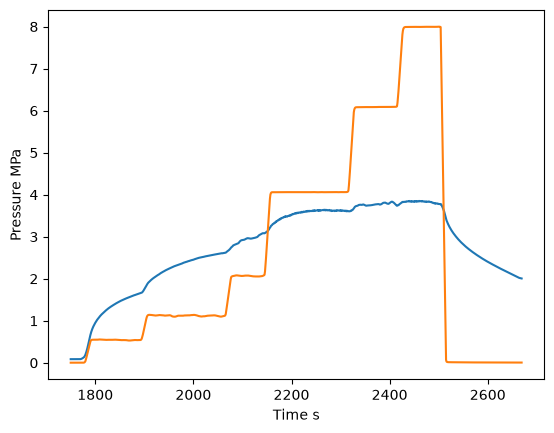

In [6]:
plt.plot(datar['Zeit [s]'],datar['Pint_downhole [MPa]'])
plt.plot(datar['Zeit [s]'],datar['Q_downhole [lpm]_s'])
plt.ylabel("Pressure MPa")
plt.xlabel("Time s")
plt.pause(1)